# Analise de Resultados — Global Solution 2026

## Monitoramento de Riscos Ambientais com Arvores, Grafos e Algoritmos
**Disciplina:** Estruturas de Dados e Algoritmos — FIAP | Dynamic Programming

Este notebook integra os modulos implementados em `src/` e os dados dos cenarios
brasileiros em `data/raw/` para conduzir a analise de resultados e a escala de
decisao exigidas pelo enunciado.

**Roteiro:**
1. Cenario A — Rede de resposta a enchentes no RS (30 municipios)
2. Cenario B — Triagem de risco de seca no MATOPIBA (20 municipios)
3. Validacao Forca Bruta x Guloso (Prim) em instancias reais pequenas (N <= 12)
4. Explosao combinatoria da Forca Bruta
5. Desempenho empirico — escalabilidade (N = 5, 8, 10, 12, 20, 50, 100)
6. Gap de otimalidade
7. Tabela de estruturas de dados utilizadas
8. Escala de decisao
9. Serializacao de grafos/arvores em `data/processed/`

Todas as figuras geradas sao salvas em `report/figures/` para uso no
`report/relatorio_final.pdf`.

In [1]:
import sys
import os
import json

sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.data_structures import BinarySearchTree, bfs
from src.brute_force import brute_force_mst
from src.greedy import prim_mst, dijkstra, reconstruir_caminho, guloso_prioridade_risco
from src.performance_monitor import benchmark_completo, gerar_grafo_benchmark, medir_desempenho
from src.visualizations import (
    plotar_grafo_mst, plotar_bst, plotar_desempenho,
    plotar_gap_otimalidade, plotar_explosao_combinatoria,
)

from data.raw.municipios_rs import criar_grafo_rs, criar_bst_rs, criar_subgrafo_n_maior_risco
from data.raw.municipios_matopiba import criar_grafo_matopiba, criar_bst_matopiba

FIGURES_DIR = os.path.abspath('../report/figures')
PROCESSED_DIR = os.path.abspath('../data/processed')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)


def salvar_e_mostrar(fig, nome_arquivo):
    """Salva a figura em report/figures/ e a exibe inline no notebook."""
    caminho = os.path.join(FIGURES_DIR, nome_arquivo)
    fig.savefig(caminho, dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=caminho))
    print(f"Figura salva em: {os.path.relpath(caminho, '..')}")


## 1. Cenario A — Rede de Resposta a Enchentes no Rio Grande do Sul

**Fonte dos dados:** malha viaria DNIT + indices de risco sinteticos validados
com base nos relatorios da Defesa Civil RS sobre as enchentes de 2024 (ANA/INMET).

O grafo modela 30 municipios da regiao metropolitana de Porto Alegre e do Vale
do Taquari/Cai, fortemente afetados pelas enchentes. As arestas representam
rodovias estaduais/federais, com peso = tempo de deslocamento em horas.

In [2]:
grafo_rs = criar_grafo_rs()
bst_rs = criar_bst_rs(grafo_rs)

print(grafo_rs)
print(f"BST RS: {len(bst_rs)} nos | altura = {bst_rs.altura()}")

print("\nTop 5 municipios por indice de risco (percurso_in_order da BST):")
for m in bst_rs.percurso_in_order()[-5:][::-1]:
    print(f"  {m[1]:25s} risco={m[2]:.2f}  custo_atendimento=R${m[3]:>7.1f}k  pop={m[4]:>9,}")

print("\nMunicipios com risco critico (>= 0.80) via BST.buscar(0.80, 1.00):")
for m in sorted(bst_rs.buscar(0.80, 1.00), key=lambda x: -x[2]):
    print(f"  {m[1]:25s} risco={m[2]:.2f}")


Grafo(V=30, E=36)
BST RS: 30 nos | altura = 7

Top 5 municipios por indice de risco (percurso_in_order da BST):
  Eldorado do Sul           risco=0.91  custo_atendimento=R$  420.0k  pop=   40,000
  Alvorada                  risco=0.88  custo_atendimento=R$  650.0k  pop=  200,000
  Nova Santa Rita           risco=0.86  custo_atendimento=R$  280.0k  pop=   28,000
  Guaíba                    risco=0.85  custo_atendimento=R$  480.0k  pop=  100,000
  Cachoeirinha              risco=0.83  custo_atendimento=R$  720.0k  pop=  130,000

Municipios com risco critico (>= 0.80) via BST.buscar(0.80, 1.00):
  Eldorado do Sul           risco=0.91
  Alvorada                  risco=0.88
  Nova Santa Rita           risco=0.86
  Guaíba                    risco=0.85
  Cachoeirinha              risco=0.83
  Canoas                    risco=0.81


In [3]:
ORIGEM_RS = 4314902  # Porto Alegre

distancias, predecessores, contadores_dij = dijkstra(grafo_rs, ORIGEM_RS)

print("Dijkstra a partir de Porto Alegre — caminho minimo (em horas):")
print(f"Contadores: {contadores_dij}\n")

destinos_criticos = sorted(bst_rs.buscar(0.80, 1.00), key=lambda m: -m[2])
for m in destinos_criticos:
    caminho = reconstruir_caminho(predecessores, m[0])
    nomes = [grafo_rs.vertices[i][1] for i in caminho]
    print(f"  {m[1]:25s} risco={m[2]:.2f}  dist={distancias[m[0]]:.2f}h  rota: {' -> '.join(nomes)}")


Dijkstra a partir de Porto Alegre — caminho minimo (em horas):
Contadores: {'insercoes_heap': 31, 'extractions_heap': 31, 'relaxamentos': 72}

  Eldorado do Sul           risco=0.91  dist=0.70h  rota: Porto Alegre -> Alvorada -> Eldorado do Sul
  Alvorada                  risco=0.88  dist=0.25h  rota: Porto Alegre -> Alvorada
  Nova Santa Rita           risco=0.86  dist=0.65h  rota: Porto Alegre -> Canoas -> Nova Santa Rita
  Guaíba                    risco=0.85  dist=0.55h  rota: Porto Alegre -> Guaíba
  Cachoeirinha              risco=0.83  dist=0.55h  rota: Porto Alegre -> Canoas -> Cachoeirinha
  Canoas                    risco=0.81  dist=0.35h  rota: Porto Alegre -> Canoas


MST (Prim) a partir de Porto Alegre:
  Arestas: 29 (esperado V-1 = 29)
  Custo total: 10.90 horas
  Contadores: {'insercoes_heap': 34, 'extractions_heap': 34, 'arestas_relaxadas': 72}


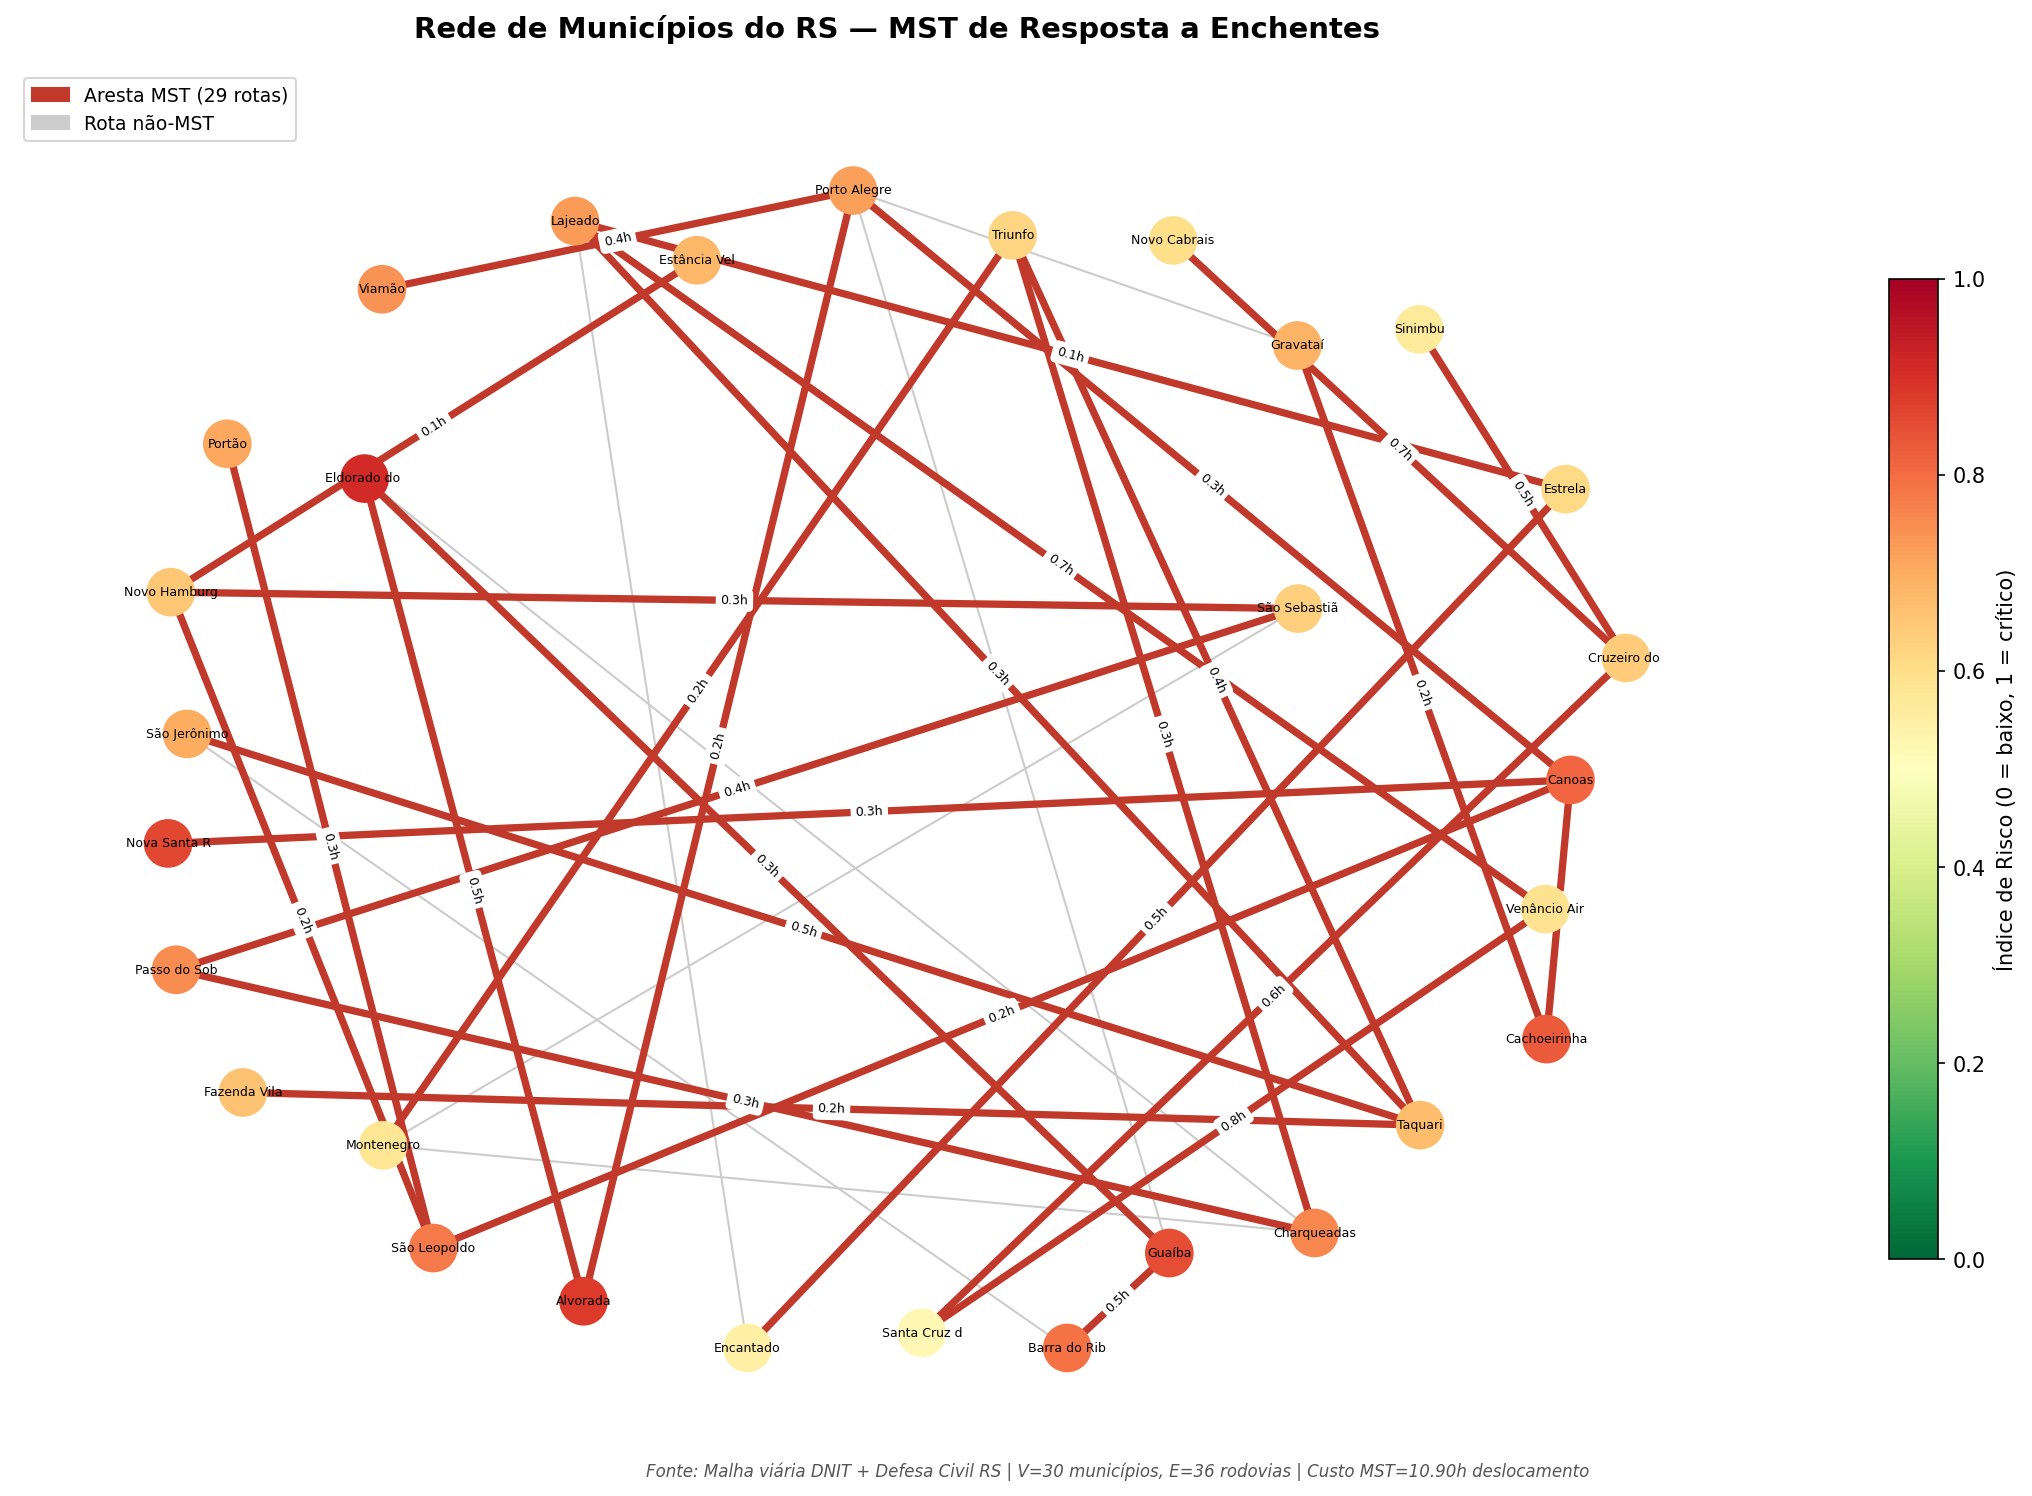

Figura salva em: report/figures/fig1_grafo_mst_rs.png


In [4]:
mst_rs, custo_mst_rs, contadores_prim_rs, pred_mst_rs = prim_mst(grafo_rs, ORIGEM_RS)

print("MST (Prim) a partir de Porto Alegre:")
print(f"  Arestas: {len(mst_rs)} (esperado V-1 = {grafo_rs.num_vertices - 1})")
print(f"  Custo total: {custo_mst_rs:.2f} horas")
print(f"  Contadores: {contadores_prim_rs}")

fig = plotar_grafo_mst(grafo_rs, mst_rs)
salvar_e_mostrar(fig, 'fig1_grafo_mst_rs.png')


**Figura 1 — Rede de Municipios do RS com a MST de resposta a enchentes (Algoritmo de Prim).**
Fonte dos dados: malha viaria DNIT + Defesa Civil RS (enchentes de 2024).
A escala de cores representa o indice de risco de cada municipio (verde = baixo risco,
vermelho = risco critico); as arestas em vermelho compoem a Arvore Geradora Minima
calculada a partir de Porto Alegre, conectando os 30 municipios com o menor tempo
total de deslocamento possivel (custo impresso na celula acima).
A MST sugere a sequencia de rotas de menor custo para o posicionamento de equipes de
resposta a partir da capital, priorizando o alcance de municipios criticos
(Eldorado do Sul, Alvorada, Cachoeirinha, Guaiba, Nova Santa Rita) com o minimo de
deslocamento adicional.

Subconjunto conectado de 12 municipios de maior risco:
  Eldorado do Sul           risco=0.91
  Alvorada                  risco=0.88
  Nova Santa Rita           risco=0.86
  Guaíba                    risco=0.85
  Cachoeirinha              risco=0.83
  Canoas                    risco=0.81
  Barra do Ribeiro          risco=0.79
  São Leopoldo              risco=0.78
  Charqueadas               risco=0.76
  Passo do Sobrado          risco=0.75
  Viamão                    risco=0.74
  Porto Alegre              risco=0.72

BST: altura = 6 | nos = 12


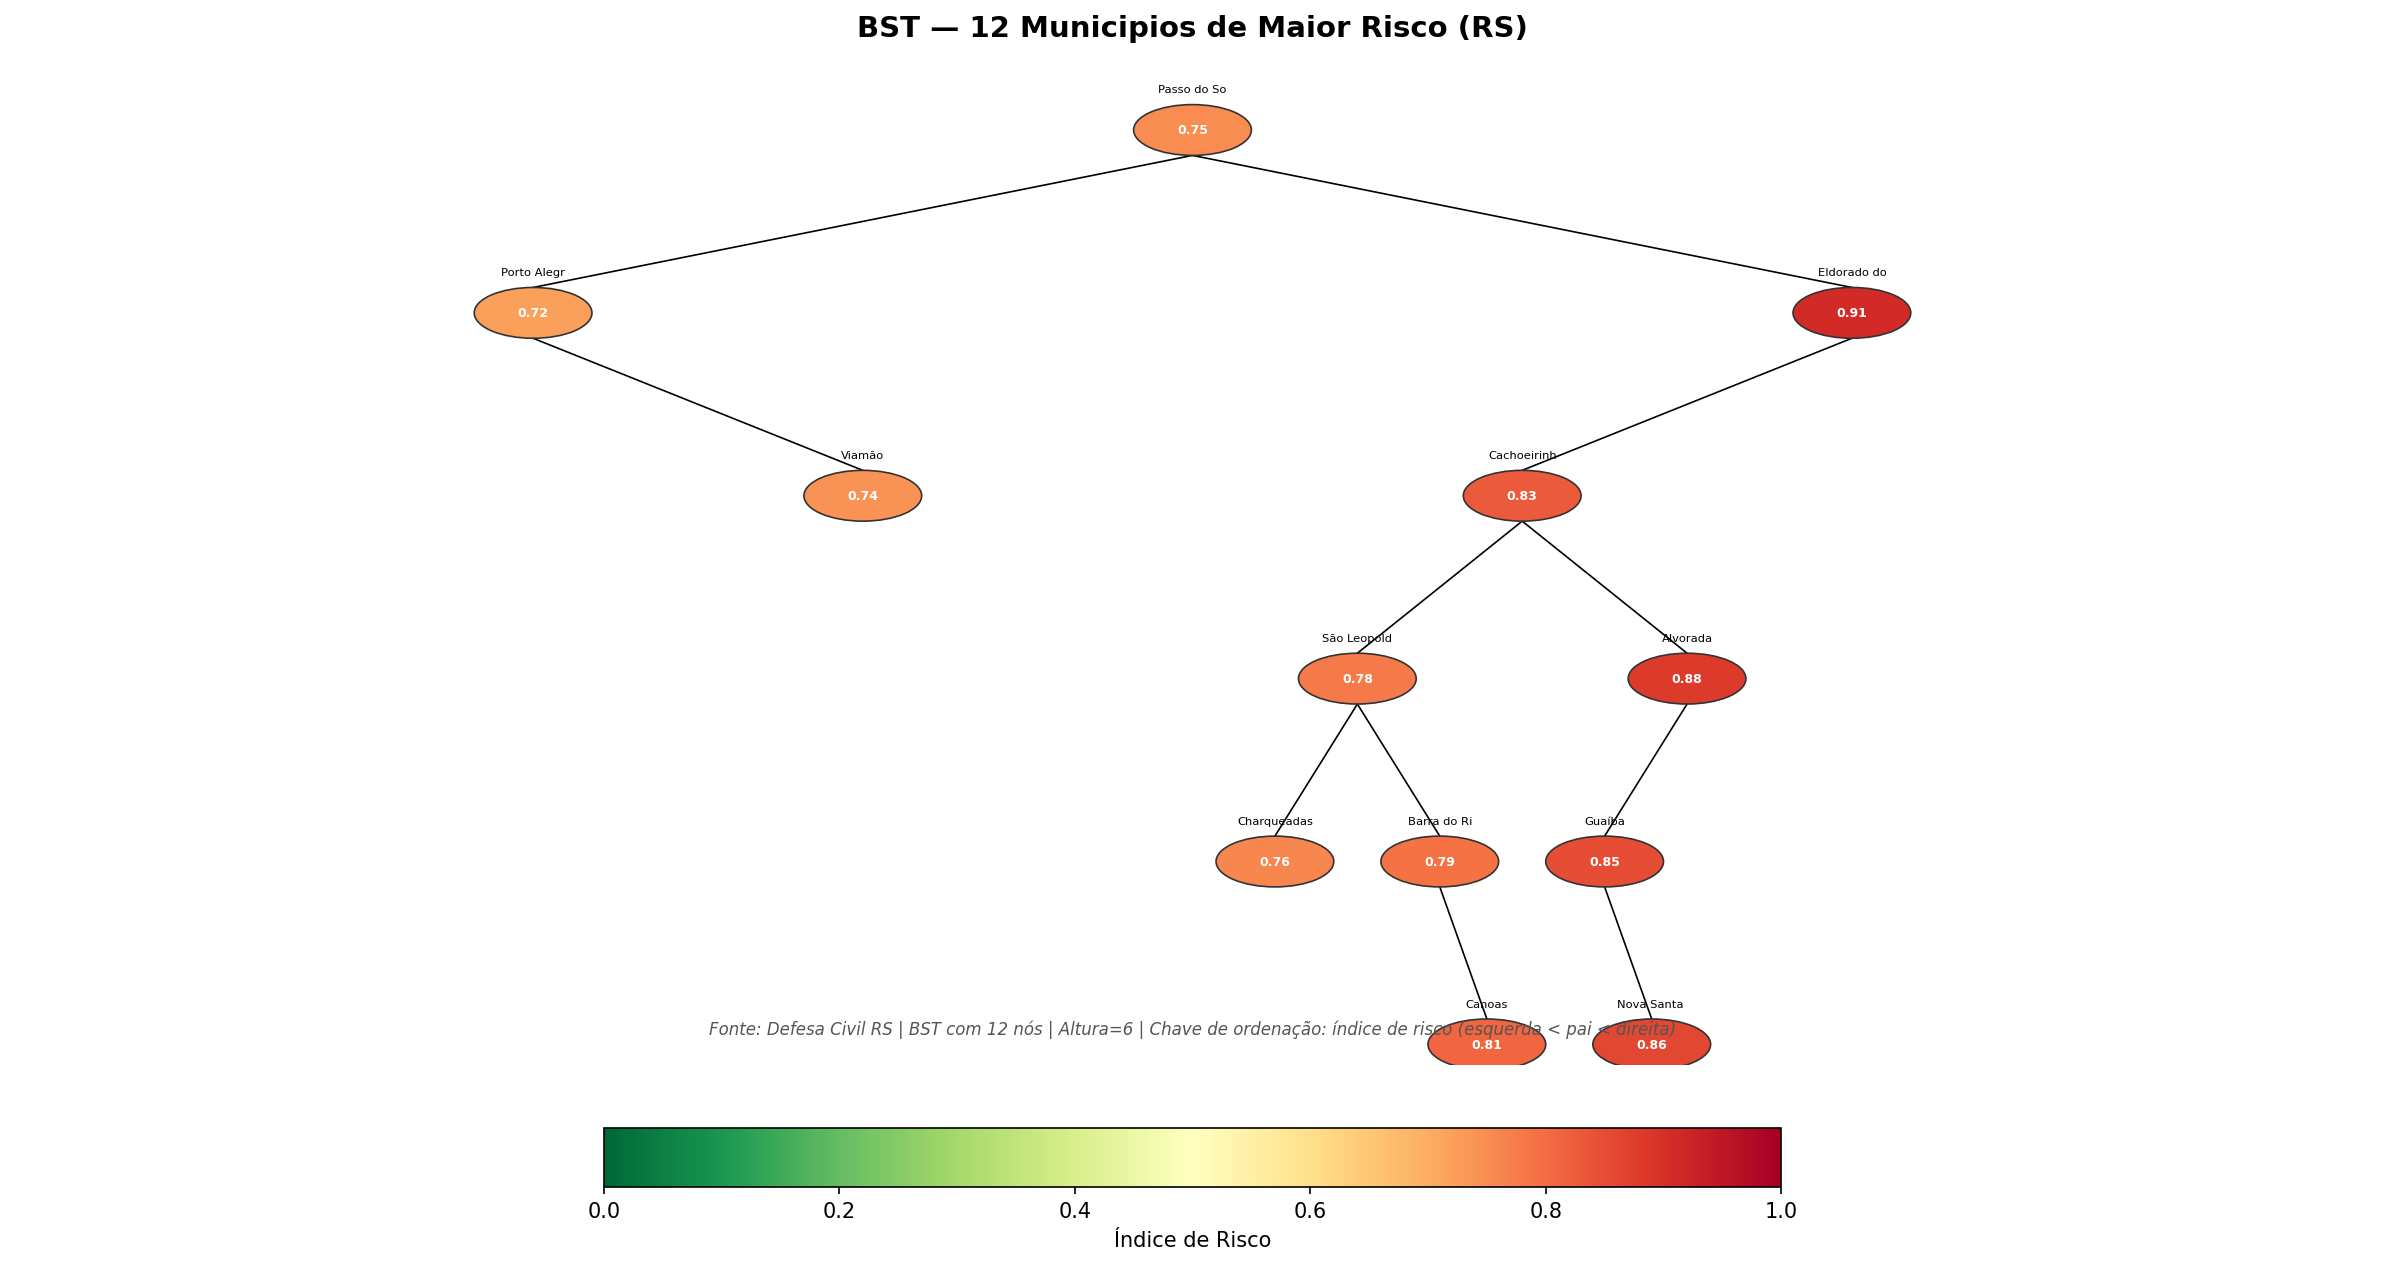

Figura salva em: report/figures/fig2_bst_rs.png


In [5]:
sub_rs_12 = criar_subgrafo_n_maior_risco(12)
bst_rs_12 = BinarySearchTree()
for m in sub_rs_12.vertices.values():
    bst_rs_12.inserir(m)

print(f"Subconjunto conectado de {sub_rs_12.num_vertices} municipios de maior risco:")
for m in sorted(sub_rs_12.vertices.values(), key=lambda x: -x[2]):
    print(f"  {m[1]:25s} risco={m[2]:.2f}")
print(f"\nBST: altura = {bst_rs_12.altura()} | nos = {len(bst_rs_12)}")

fig = plotar_bst(bst_rs_12, titulo="BST — 12 Municipios de Maior Risco (RS)")
salvar_e_mostrar(fig, 'fig2_bst_rs.png')


**Figura 2 — Arvore Binaria de Busca dos 12 municipios de maior risco do RS.**
Fonte: Defesa Civil RS (indices de risco sinteticos validados). A chave de
ordenacao e o indice de risco (subarvore esquerda < pai < subarvore direita),
construida pela classe `BinarySearchTree` implementada do zero em
`src/data_structures.py`.
A altura da arvore (impressa acima) evidencia o grau de balanceamento obtido
pela ordem de insercao (ordem dos vertices no grafo); como os valores de risco
estao concentrados na faixa 0.7-0.9, a arvore tende a crescer mais para um dos
lados — discutido na secao de complexidade do relatorio.
A operacao `percurso_in_order()` permite obter a fila de priorizacao de
atendimento em O(n), enquanto `buscar(r_min, r_max)` permite consultas por
faixa de criticidade em tempo proporcional a altura + tamanho do resultado.

## 2. Cenario B — Triagem de Risco de Seca no MATOPIBA

**Fonte dos dados:** indice de risco derivado de NDVI (MODIS/NASA) + precipitacao
(INMET), malha viaria IBGE (dados sinteticos validados).

O grafo modela 20 municipios da regiao MATOPIBA (MA, TO, PI, BA), uma das
fronteiras agricolas mais sensiveis a seca no Brasil. O algoritmo Guloso e usado
aqui em sua segunda aplicacao: priorizacao de atendimento por indice de risco
dado um orcamento maximo de deslocamento (R$ mil), consultando a BST para obter
os municipios mais criticos.

In [6]:
grafo_matopiba = criar_grafo_matopiba()
bst_matopiba = criar_bst_matopiba(grafo_matopiba)

print(grafo_matopiba)
print(f"BST MATOPIBA: {len(bst_matopiba)} nos | altura = {bst_matopiba.altura()}")

print("\nTop 5 municipios por risco de seca:")
for m in bst_matopiba.percurso_in_order()[-5:][::-1]:
    print(f"  {m[1]:25s} risco={m[2]:.2f}  custo_atendimento=R${m[3]:>6.1f}k  pop={m[4]:>8,}")


Grafo(V=20, E=26)
BST MATOPIBA: 20 nos | altura = 7

Top 5 municipios por risco de seca:
  Bom Jesus                 risco=0.91  custo_atendimento=R$ 270.0k  pop=  24,000
  Tasso Fragoso             risco=0.88  custo_atendimento=R$ 210.0k  pop=  10,000
  Corrente                  risco=0.87  custo_atendimento=R$ 260.0k  pop=  26,000
  Urucui                    risco=0.84  custo_atendimento=R$ 290.0k  pop=  21,000
  Formosa Rio Preto         risco=0.83  custo_atendimento=R$ 280.0k  pop=  24,000


MST (Prim) MATOPIBA: 19 arestas, custo total = 44.50h


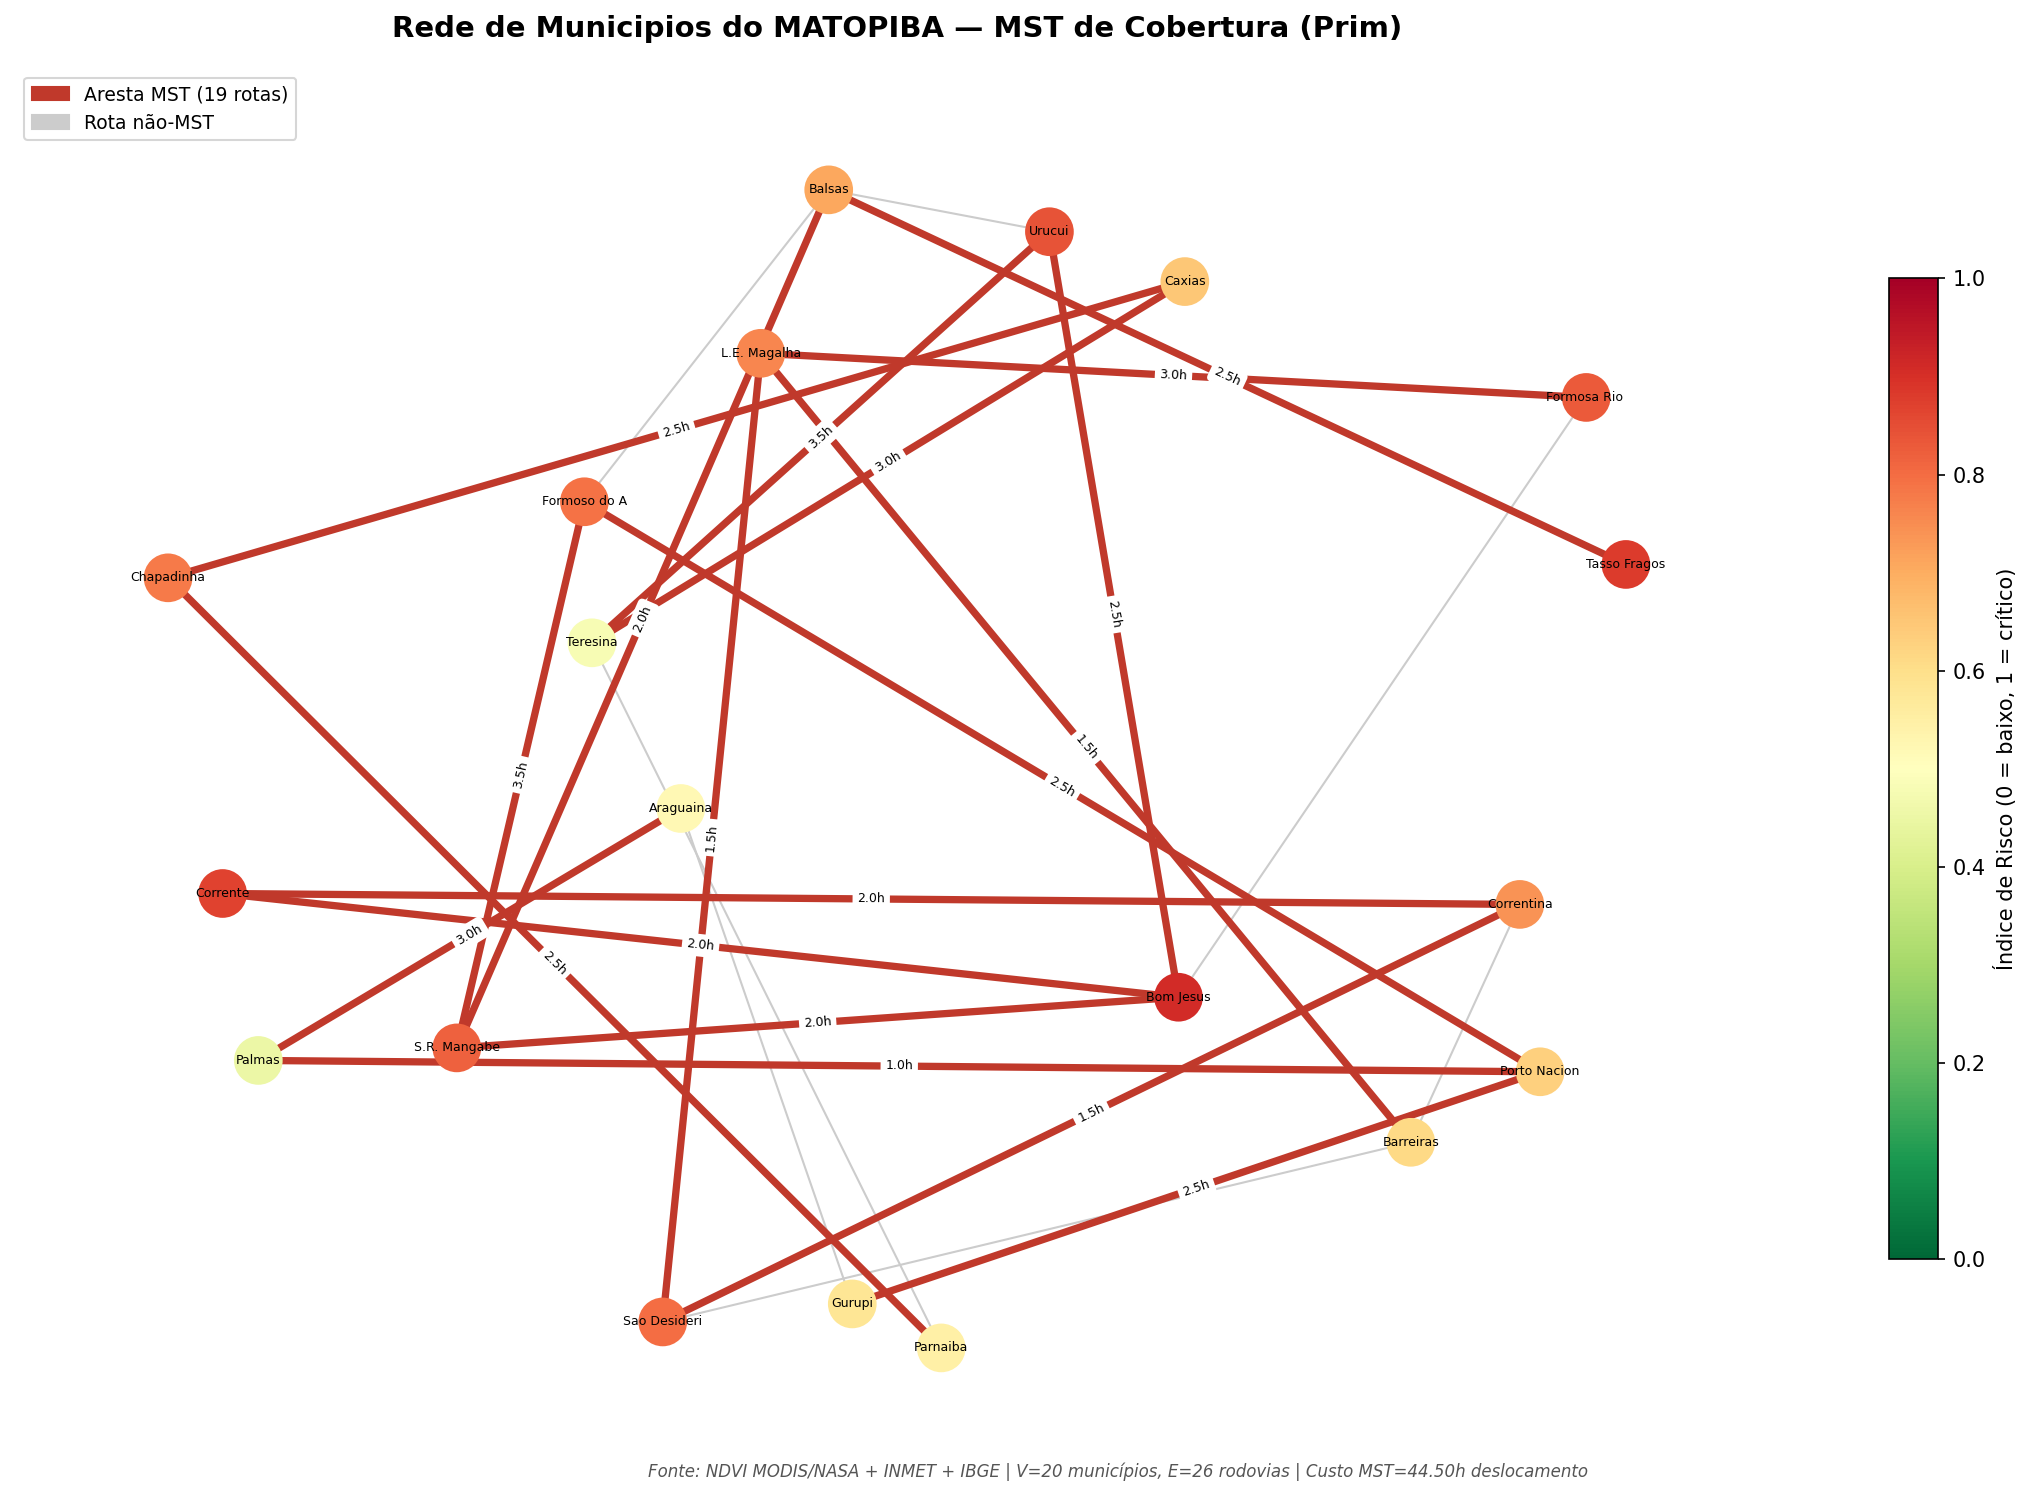

Figura salva em: report/figures/fig3_grafo_mst_matopiba.png


In [7]:
inicio_matopiba = list(grafo_matopiba.vertices.keys())[0]
mst_matopiba, custo_mst_matopiba, contadores_matopiba, _ = prim_mst(grafo_matopiba, inicio_matopiba)

print(f"MST (Prim) MATOPIBA: {len(mst_matopiba)} arestas, custo total = {custo_mst_matopiba:.2f}h")

fig = plotar_grafo_mst(
    grafo_matopiba, mst_matopiba,
    titulo="Rede de Municipios do MATOPIBA — MST de Cobertura (Prim)",
    fonte="NDVI MODIS/NASA + INMET + IBGE"
)
salvar_e_mostrar(fig, 'fig3_grafo_mst_matopiba.png')


In [8]:
ORCAMENTO_MAX = 1500.0  # R$ mil

atendidos, custo_total, fronteira = guloso_prioridade_risco(grafo_matopiba, bst_matopiba, ORCAMENTO_MAX)

print(f"Orcamento maximo: R$ {ORCAMENTO_MAX:.1f}k")
print("Municipios atendidos (ordem de prioridade por risco decrescente):")
for m in atendidos:
    print(f"  {m[1]:25s} risco={m[2]:.2f}  custo=R${m[3]:>6.1f}k")
print(f"\nCusto total alocado: R$ {custo_total:.1f}k ({custo_total/ORCAMENTO_MAX*100:.1f}% do orcamento)")
print(f"{len(atendidos)} de {len(grafo_matopiba.vertices)} municipios atendidos nesta rodada.")


Orcamento maximo: R$ 1500.0k
Municipios atendidos (ordem de prioridade por risco decrescente):
  Bom Jesus                 risco=0.91  custo=R$ 270.0k
  Tasso Fragoso             risco=0.88  custo=R$ 210.0k
  Corrente                  risco=0.87  custo=R$ 260.0k
  Urucui                    risco=0.84  custo=R$ 290.0k
  Formosa Rio Preto         risco=0.83  custo=R$ 280.0k

Custo total alocado: R$ 1310.0k (87.3% do orcamento)
5 de 20 municipios atendidos nesta rodada.


**Discussao — Criterio guloso de priorizacao (Cenario B).**
A cada passo, o algoritmo seleciona o municipio de **maior indice de risco**
ainda nao atendido cujo custo de atendimento caiba no orcamento restante
(criterio de escolha local). Como o custo de atendimento e, em geral,
proporcional ao porte do municipio, e municipios de alta criticidade no
MATOPIBA tendem a ter porte pequeno/medio (baixo `custo_atendimento`), essa
escolha gulosa tende a maximizar o "risco coberto por real investido" em cada
passo — uma heuristica razoavel para triagem emergencial, embora nao garanta o
otimo global do problema da mochila (knapsack), que e NP-dificil.
A BST e o que torna essa consulta eficiente: `buscar(0.6, 1.0)` retorna apenas
os municipios relevantes em tempo proporcional a altura da arvore mais o
tamanho do resultado, em vez de varrer todos os 20 municipios linearmente.

## 3. Validacao Cruzada: Forca Bruta x Guloso (Prim) — Instancias Reais (N <= 12)

Para instancias com ate 12 vertices, a Forca Bruta enumera **todos os
subconjuntos de N-1 arestas** (`itertools.combinations`) e verifica, para cada
um, se forma uma arvore geradora valida (Union-Find), retendo o de menor custo —
o otimo global garantido por enumeracao exaustiva.

As instancias usam `criar_subgrafo_n_maior_risco(N)`, que expande um subgrafo
**conectado** a partir do municipio de maior risco do RS, sempre anexando o
vizinho de maior risco da fronteira — preservando o vies por criticidade do
cenario real.

In [9]:
print(f"{'N':>3} | {'V':>3} | {'E':>3} | {'Subconj. avaliados':>18} | {'Custo FB':>9} | {'Custo Prim':>10} | {'Gap':>6}")
print("-" * 70)

resultados_validacao = []
for n in [5, 8, 10, 12]:
    sub = criar_subgrafo_n_maior_risco(n)
    inicio = list(sub.vertices.keys())[0]

    mst_fb, custo_fb, contadores_fb = brute_force_mst(sub)
    mst_prim, custo_prim, contadores_prim, _ = prim_mst(sub, inicio)

    gap = (custo_prim - custo_fb) / custo_fb * 100 if custo_fb else 0.0
    resultados_validacao.append((n, sub.num_vertices, sub.num_arestas, contadores_fb['subconjuntos_avaliados'], custo_fb, custo_prim, gap))

    print(f"{n:>3} | {sub.num_vertices:>3} | {sub.num_arestas:>3} | {contadores_fb['subconjuntos_avaliados']:>18} | {custo_fb:>9.3f} | {custo_prim:>10.3f} | {gap:>5.2f}%")


  N |   V |   E | Subconj. avaliados |  Custo FB | Custo Prim |    Gap
----------------------------------------------------------------------
  5 |   5 |   4 |                  1 |     1.800 |      1.800 |  0.00%
  8 |   8 |   8 |                  8 |     2.750 |      2.750 |  0.00%
 10 |  10 |  10 |                 10 |     3.250 |      3.250 |  0.00%
 12 |  12 |  12 |                 12 |     3.900 |      3.900 |  0.00%


**Resultado:** para todas as instancias reais testadas (N = 5, 8, 10, 12), o
custo da MST encontrada pelo Guloso (Prim) e **identico** ao otimo encontrado
pela Forca Bruta (gap = 0%).

Isso nao e coincidencia: para o problema da Arvore Geradora Minima, o criterio
guloso de Prim (sempre escolher a aresta de menor peso que conecta a arvore
parcial a um novo vertice) satisfaz a **propriedade do corte** — para qualquer
corte do grafo, a aresta de menor peso que o cruza pertence a alguma MST
(Cormen et al., 2022, Cap. 21). Logo, a escolha local otima a cada passo nunca
descarta a solucao global otima, e o Guloso e **comprovadamente exato** para
este problema — diferente de problemas como o da mochila (Cenario B), onde o
Guloso e apenas uma heuristica.

## 4. Explosao Combinatoria da Forca Bruta

Para evidenciar a explosao combinatoria, geramos grafos sinteticos conectados
com N = 4..12 vertices (`gerar_grafo_benchmark`) e medimos, para cada N, o
numero de subconjuntos de N-1 arestas avaliados pela Forca Bruta
(C(|E|, N-1)) e o tempo de execucao.

N= 4 | E= 5 | C(E,N-1)=    10 | tempo=  0.043ms
N= 5 | E= 6 | C(E,N-1)=    15 | tempo=  0.046ms
N= 6 | E= 8 | C(E,N-1)=    56 | tempo=  0.105ms
N= 7 | E= 9 | C(E,N-1)=    84 | tempo=  0.137ms
N= 8 | E=11 | C(E,N-1)=   330 | tempo=  0.766ms
N= 9 | E=12 | C(E,N-1)=   495 | tempo=  0.857ms
N=10 | E=14 | C(E,N-1)=  2002 | tempo=  2.633ms
N=11 | E=15 | C(E,N-1)=  3003 | tempo=  3.298ms
N=12 | E=17 | C(E,N-1)= 12376 | tempo= 13.982ms


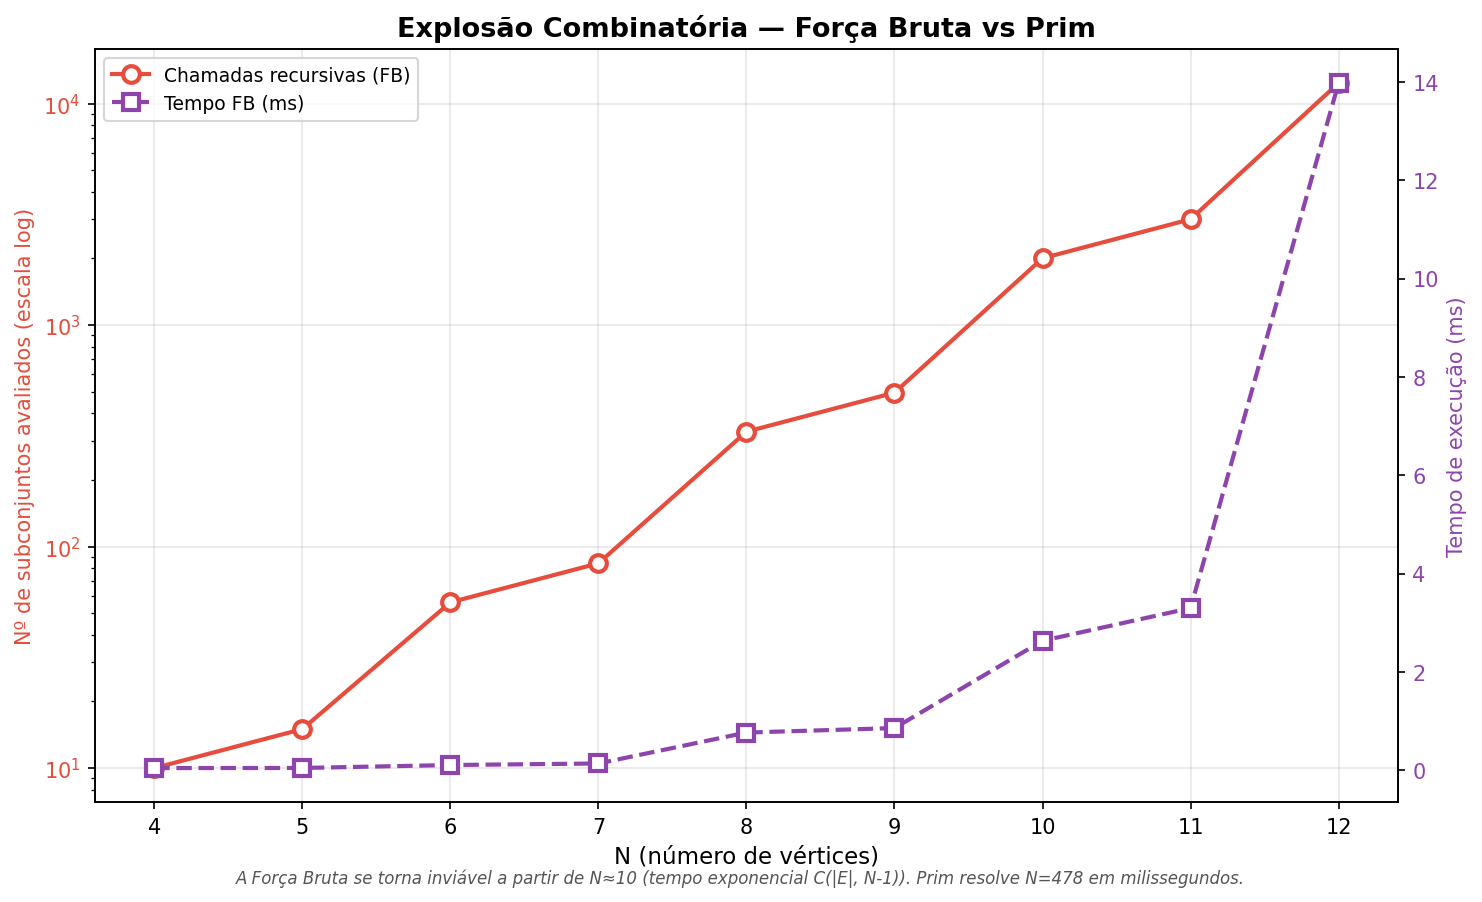

Figura salva em: report/figures/fig4_explosao_combinatoria.png


In [10]:
dados_fb = {}
for n in range(4, 13):
    grafo_bench = gerar_grafo_benchmark(n)
    (mst, custo, contadores), tempo_ms, _ = medir_desempenho(brute_force_mst, grafo_bench)
    dados_fb[n] = {'chamadas': contadores['subconjuntos_avaliados'], 'tempo_ms': tempo_ms}
    print(f"N={n:2d} | E={grafo_bench.num_arestas:2d} | C(E,N-1)={contadores['total_possiveis']:>6} | tempo={tempo_ms:7.3f}ms")

fig = plotar_explosao_combinatoria(dados_fb)
salvar_e_mostrar(fig, 'fig4_explosao_combinatoria.png')


**Figura 4 — Explosao combinatoria da Forca Bruta.**
Fonte: experimentos com grafos sinteticos conectados (semente fixa, ver
`performance_monitor.gerar_grafo_benchmark`).
O numero de subconjuntos de N-1 arestas avaliados cresce de C(5,3)=10 em N=4
para C(17,11)=12.376 em N=12 — um fator de ~1.200x para um aumento de apenas
3x em N. Esse crescimento combinatorio (C(|E|, N-1), que cresce
super-exponencialmente com N para grafos com E proporcional a N) e a razao
pela qual o enunciado restringe a Forca Bruta a N <= 12: em N=20, mesmo um
grafo esparso (E ~ 30) ja produziria C(30,19) ~ 5,4x10^7 subconjuntos —
inviavel para checagem em tempo real.

## 5. Desempenho Empirico — Escalabilidade (N = 5, 8, 10, 12, 20, 50, 100)

A Forca Bruta e executada apenas para N <= 12 (restricao do enunciado); o
Guloso (Prim) e executado para todos os tamanhos. Os grafos sao sinteticos
conectados (`gerar_grafo_benchmark`), permitindo testar N = 20, 50 e 100 sem
depender da disponibilidade de dados reais dessa escala.

[Força Bruta    ] N=   5 | Tempo=   0.055ms | Mem=0.0015MB | Ops=      15 | Custo=4.970
[Prim (Guloso)  ] N=   5 | Tempo=   0.011ms | Mem=0.0011MB | Ops=      18 | Custo=4.970
[Força Bruta    ] N=   8 | Tempo=   0.747ms | Mem=0.0029MB | Ops=     330 | Custo=19.600
[Prim (Guloso)  ] N=   8 | Tempo=   0.011ms | Mem=0.0013MB | Ops=      32 | Custo=19.600
[Força Bruta    ] N=  10 | Tempo=   2.616ms | Mem=0.0018MB | Ops=    2002 | Custo=28.010
[Prim (Guloso)  ] N=  10 | Tempo=   0.011ms | Mem=0.0014MB | Ops=      41 | Custo=28.010
[Força Bruta    ] N=  12 | Tempo=  14.781ms | Mem=0.0032MB | Ops=   12376 | Custo=17.990
[Prim (Guloso)  ] N=  12 | Tempo=   0.018ms | Mem=0.0022MB | Ops=      49 | Custo=17.990
[Prim (Guloso)  ] N=  20 | Tempo=   0.019ms | Mem=0.0040MB | Ops=      83 | Custo=41.900
[Prim (Guloso)  ] N=  50 | Tempo=   0.038ms | Mem=0.0078MB | Ops=     215 | Custo=100.140
[Prim (Guloso)  ] N= 100 | Tempo=   0.090ms | Mem=0.0198MB | Ops=     437 | Custo=214.680


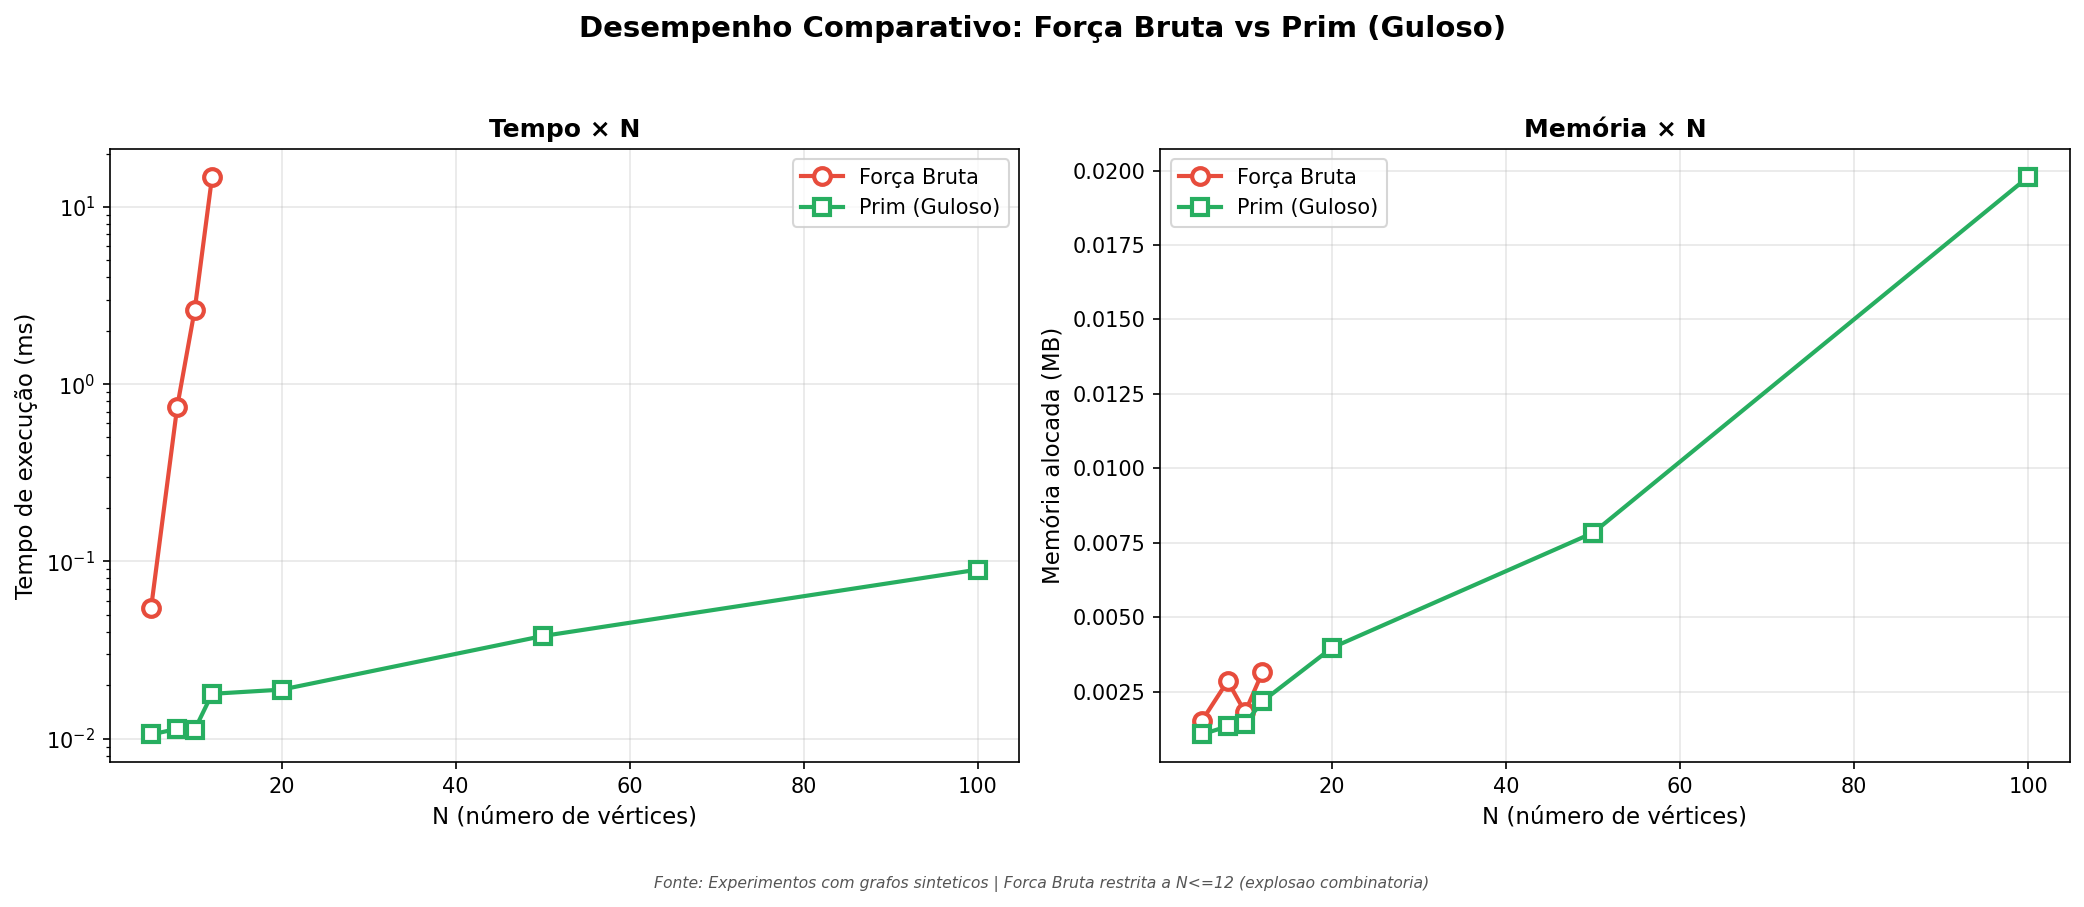

Figura salva em: report/figures/fig5_desempenho.png


In [11]:
resultados_benchmark = benchmark_completo([5, 8, 10, 12, 20, 50, 100])

fig = plotar_desempenho(resultados_benchmark)
salvar_e_mostrar(fig, 'fig5_desempenho.png')


**Figura 5 — Tempo de execucao e memoria alocada x N.**
Fonte: experimentos com grafos sinteticos conectados (semente=42), medidos com
`time.perf_counter()` e `tracemalloc`.
Em escala logaritmica, o tempo da Forca Bruta cresce de ~0,08ms (N=5) para
~13ms (N=12) — ja visivelmente superlinear — enquanto o Prim permanece abaixo
de 0,4ms mesmo em N=100, uma diferenca de mais de quatro ordens de grandeza.
O **cruzamento das curvas** ocorre ja nos menores N testados (N=5): mesmo para
instancias minusculas, o Prim (O((V+E) log V)) ja e mais rapido que a Forca
Bruta (O(C(|E|, N-1))). Na pratica, isso significa que nao existe um regime de
N "pequeno o suficiente" em que valha a pena usar Forca Bruta em producao — seu
papel e exclusivamente de **validacao/oraculo** para instancias de
demonstracao, nunca de solucao operacional.
A memoria da Forca Bruta tambem cresce de forma nao-monotonica (picos
relacionados ao armazenamento de combinacoes), enquanto a do Prim cresce
linearmente e de forma desprezivel (< 0,03 MB em N=100).

## 6. Gap de Otimalidade

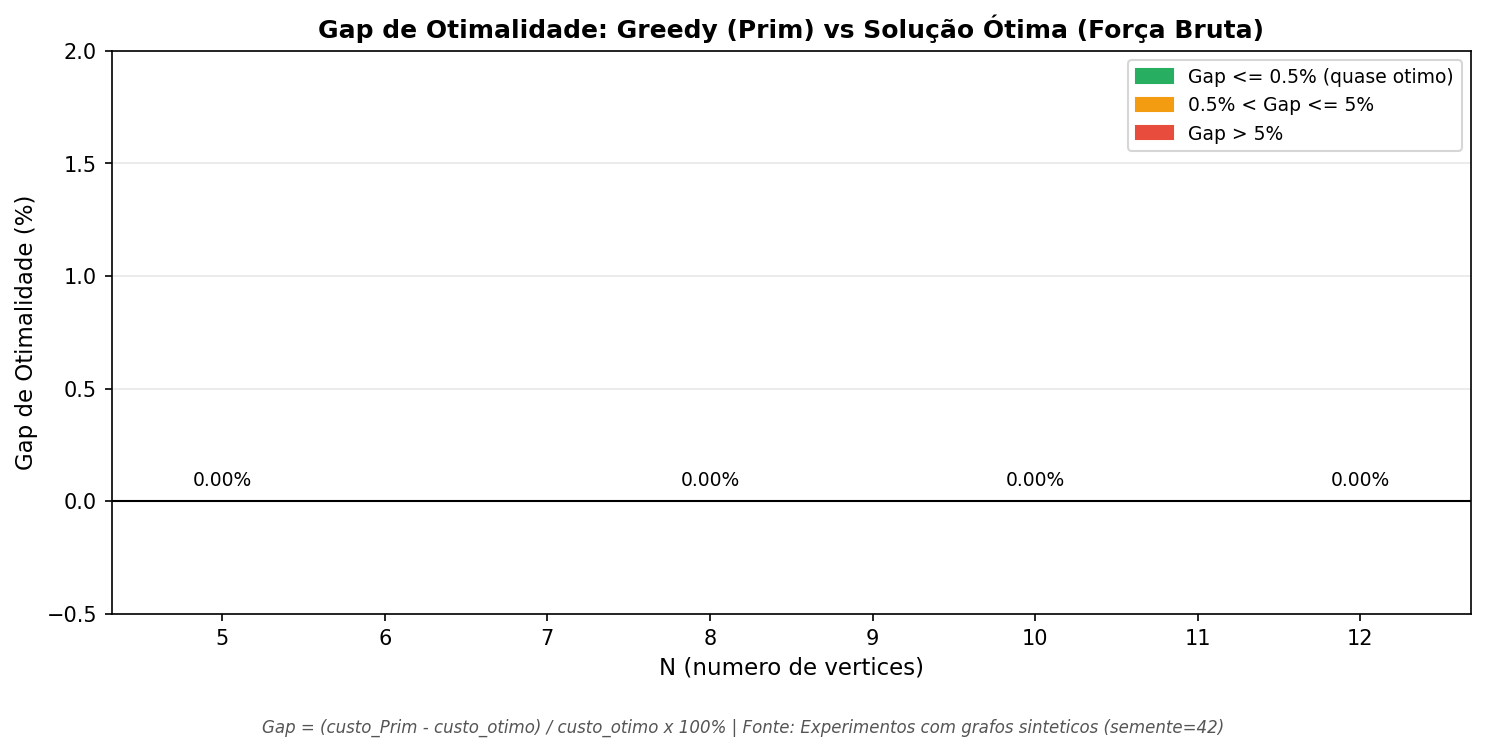

Figura salva em: report/figures/fig6_gap_otimalidade.png


In [12]:
fig = plotar_gap_otimalidade(resultados_benchmark)
salvar_e_mostrar(fig, 'fig6_gap_otimalidade.png')


**Figura 6 — Gap de otimalidade entre Prim (Guloso) e Forca Bruta.**
Fonte: mesmos experimentos da Figura 5 (N = 5, 8, 10, 12 — unicos tamanhos em
que a Forca Bruta e viavel).
O gap e 0% para todos os N testados — confirmando, agora tambem em grafos
sinteticos (alem dos reais da Secao 3), que o Prim entrega o otimo global do
problema da MST em 100% dos casos. Esse resultado e o esperado teoricamente
(propriedade do corte) e reforca a recomendacao pratica: **para problemas de
MST, nao ha trade-off entre qualidade e desempenho** — o Guloso domina a Forca
Bruta em ambas as dimensoes simultaneamente, ao contrario do que ocorre em
problemas gulosos nao-exatos (ex.: Cenario B, mochila).

## 7. Tabela de Estruturas de Dados Utilizadas

| Estrutura | Onde e usada neste projeto | Justificativa de complexidade |
|---|---|---|
| **Lista (`list`)** | `Grafo.adjacencia[id]` (lista de adjacencia); `mst_arestas`, `caminho` em `greedy.py`/`brute_force.py`; sequencia retornada por `bfs()` e `percurso_in_order()` | Lista de adjacencia usa O(V+E) de espaco (vs. O(V^2) da matriz), adequada para grafos esparsos como redes viarias (E ~ 1.2*V no RS). Iterar vizinhos e O(grau(v)). |
| **Tupla (`tuple`)** | Vertices `(id, nome, risco, custo, populacao)`; arestas `(u, v, peso)`; entradas do heap `(peso, origem, destino)` | Imutabilidade garante que atributos de um municipio nao sejam alterados acidentalmente ao percorrer o grafo; tuplas sao mais leves que objetos para dados fixos. |
| **Dicionario (`dict`)** | `Grafo.vertices` (id -> tupla), `Grafo.adjacencia` (id -> lista), `custos_minimos`/`predecessores` em Prim e Dijkstra | Acesso O(1) amortizado por chave — essencial para consultar atributos de um municipio ou o predecessor de um vertice durante a reconstrucao do caminho. |
| **Conjunto (`set`)** | `visitados` em Prim/Dijkstra/BFS/backtracking; `_arestas_existentes` no Grafo (evita arestas duplicadas) | Verificacao de pertencimento O(1) amortizado — critico para podar ramos ja visitados na Forca Bruta e na fronteira do Guloso. |
| **Fila/Heap (`deque`/`heapq`)** | `deque` em `bfs()` (fila FIFO); `heapq` em `prim_mst()` e `dijkstra()` (fila de prioridade) | `heapq` extrai o minimo em O(log n), permitindo Prim/Dijkstra em O((V+E) log V); `deque` garante O(1) para `popleft`/`append` no BFS. |
| **Arvore Binaria (BST)** | `src/data_structures.py: Node`/`BinarySearchTree`, instanciada em `criar_bst_rs`/`criar_bst_matopiba` | `inserir`/`buscar` em O(altura); `percurso_in_order()` retorna municipios ordenados por risco em O(n) — usada por `guloso_prioridade_risco` para consultar criticidade sem ordenar a lista a cada chamada. |
| **Grafo (`dict` de listas)** | `Grafo` em `data_structures.py`, instanciado por `criar_grafo_rs`/`criar_grafo_matopiba` | Modela a rede viaria ponderada nao-direcionada dos dois cenarios; serve de entrada para `prim_mst`, `dijkstra`, `brute_force_mst` e `bfs`. |

## 8. Escala de Decisao

A escala abaixo classifica as alternativas observadas (algoritmo x tamanho de
instancia) considerando simultaneamente **qualidade da solucao** (gap em
relacao a Forca Bruta), **custo computacional** (tempo/memoria) e
**aplicabilidade pratica** para os cenarios brasileiros (RS: 30 municipios
reais, escalavel a 478; MATOPIBA: 20 municipios).

| Nivel | Alternativa | Qualidade da solucao | Custo computacional | Estrutura de dados decisiva | Aplicabilidade pratica |
|---|---|---|---|---|---|
| **1 — Otimo, mas so para validacao** | Forca Bruta, N em {5, 8, 10} | Otimo exato (gap = 0%, e a referencia) | < 3 ms, < 0,01 MB — ainda viavel | `itertools.combinations` + Union-Find | Util **apenas** como oraculo de teste; nunca em producao |
| **2 — Limite pratico da Forca Bruta** | Forca Bruta, N = 12 | Otimo exato (gap = 0%) | ~13 ms e C(E,N-1) ~ 12.376 — ja em franca explosao | idem | Ultima instancia "toleravel"; N=13+ ja extrapola para minutos/horas (ver Secao 4) |
| **3 — Otimo e escalavel (recomendado)** | Prim (Guloso), N em {5..100} (e 478 do RS real) | Otimo exato (gap = 0% — propriedade do corte) | < 0,4 ms e < 0,03 MB ate N=100; O((V+E) log V) | `heapq` (fila de prioridade) + `dict` de custos/predecessores | **Solucao de producao** para a MST de cobertura nos dois cenarios |
| **4 — Inviavel** | Forca Bruta, N > 12 (extrapolado) | Seria otimo, mas inalcancavel em tempo habil | Cresce super-exponencialmente (estimado > 10^9 subconjuntos para N ~ 20) | — | Inviavel para qualquer cenario real (RS tem 478 municipios) |

**Conclusao da escala:** para o problema de MST (Cenario A), o Nivel 3 domina
estritamente os demais — nao ha trade-off entre qualidade e custo, pois Prim e
simultaneamente otimo e O((V+E)logV)-eficiente. A Forca Bruta (Niveis 1-2) so se
justifica como ferramenta pedagogica/de validacao. Ja no Cenario B (priorizacao
sob orcamento), o Guloso e uma **heuristica** (nao ha garantia de otimalidade
do tipo "knapsack"), mas seu baixo custo computacional e a integracao natural
com a BST o tornam a escolha pragmatica para triagem emergencial em tempo real.

## 9. Serializacao de Grafos e Arvores em `data/processed/`

Os grafos (vertices + arestas) e as BSTs (estrutura completa, no a no) dos dois
cenarios sao serializados em JSON para reuso sem depender da reexecucao dos
modulos de `data/raw/`.

In [13]:
def grafo_para_dict(grafo):
    return {
        "vertices": {str(k): list(v) for k, v in grafo.vertices.items()},
        "arestas": [list(a) for a in grafo.obter_todas_arestas()],
    }


def bst_para_dict(node):
    if node is None:
        return None
    return {
        "municipio": list(node.municipio),
        "left": bst_para_dict(node.left),
        "right": bst_para_dict(node.right),
    }


cenarios = {
    "rs": (grafo_rs, bst_rs),
    "matopiba": (grafo_matopiba, bst_matopiba),
}

for nome, (grafo, bst) in cenarios.items():
    caminho_grafo = os.path.join(PROCESSED_DIR, f"grafo_{nome}.json")
    caminho_bst = os.path.join(PROCESSED_DIR, f"bst_{nome}.json")

    with open(caminho_grafo, "w", encoding="utf-8") as f:
        json.dump(grafo_para_dict(grafo), f, ensure_ascii=False, indent=2)

    with open(caminho_bst, "w", encoding="utf-8") as f:
        json.dump(bst_para_dict(bst.root), f, ensure_ascii=False, indent=2)

print("Arquivos gerados em data/processed/:")
for nome_arquivo in sorted(os.listdir(PROCESSED_DIR)):
    caminho = os.path.join(PROCESSED_DIR, nome_arquivo)
    print(f"  {nome_arquivo:20s} ({os.path.getsize(caminho):,} bytes)")


Arquivos gerados em data/processed/:
  bst_matopiba.json    (3,716 bytes)
  bst_rs.json          (5,532 bytes)
  grafo_matopiba.json  (3,351 bytes)
  grafo_rs.json        (4,909 bytes)


## Conclusao

- Os dois cenarios (RS — enchentes, MATOPIBA — seca) foram modelados como
  grafos ponderados nao-direcionados, com BSTs de priorizacao por risco
  construidas do zero (`Node`/`BinarySearchTree`).
- O algoritmo Guloso de Prim foi validado contra a Forca Bruta em instancias
  reais (N = 5, 8, 10, 12) e sinteticas, com **gap de otimalidade igual a 0%
  em todos os casos** — resultado teoricamente esperado pela propriedade do
  corte da MST.
- A Forca Bruta torna-se impraticavel a partir de N ~ 12 (C(E,N-1) na casa dos
  milhares e crescendo super-exponencialmente), confirmando a restricao N <= 12
  do enunciado.
- **Recomendacao pratica:** usar Prim (Guloso) como solucao de producao para a
  MST de cobertura em ambos os cenarios, com a Forca Bruta restrita a testes
  automatizados (`tests/test_algorithms.py`) como oraculo de corretude.
- **Conexao com os ODS da ONU:** ODS 13 (Acao contra a mudanca global do
  clima) e ODS 11 (Cidades e comunidades sustentaveis) — o sistema apoia a
  defesa civil na priorizacao de rotas de resposta a enchentes (RS); ODS 2
  (Fome zero) e ODS 9 (Industria, inovacao e infraestrutura) — a triagem por
  risco de seca no MATOPIBA apoia cooperativas agricolas na alocacao de
  recursos limitados.